In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier

In [4]:
df = pd.read_csv("german_credit_data.csv")

df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [5]:
print(df.shape)
print(df.columns)
print(df.info())

(1000, 11)
Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB
None


In [6]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [7]:
df.fillna(df.mode().iloc[0], inplace=True)

In [8]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose,0


In [9]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,1,2,1,0,0,1169,6,5,1
1,1,22,0,2,1,0,1,5951,48,5,0
2,2,49,1,1,1,0,0,2096,12,3,1
3,3,45,1,2,0,0,0,7882,42,4,1
4,4,53,1,2,0,0,0,4870,24,1,0


In [10]:
X = df.drop("Risk", axis=1)
y = df["Risk"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [13]:
y_pred = model.predict(X_test)

In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.705


In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.24      0.32        59
           1       0.74      0.90      0.81       141

    accuracy                           0.70       200
   macro avg       0.62      0.57      0.57       200
weighted avg       0.67      0.70      0.67       200



In [16]:
roc = roc_auc_score(y_test, y_pred)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.5689986777256881


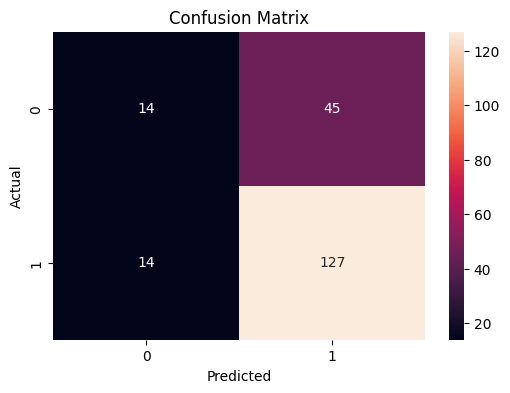

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

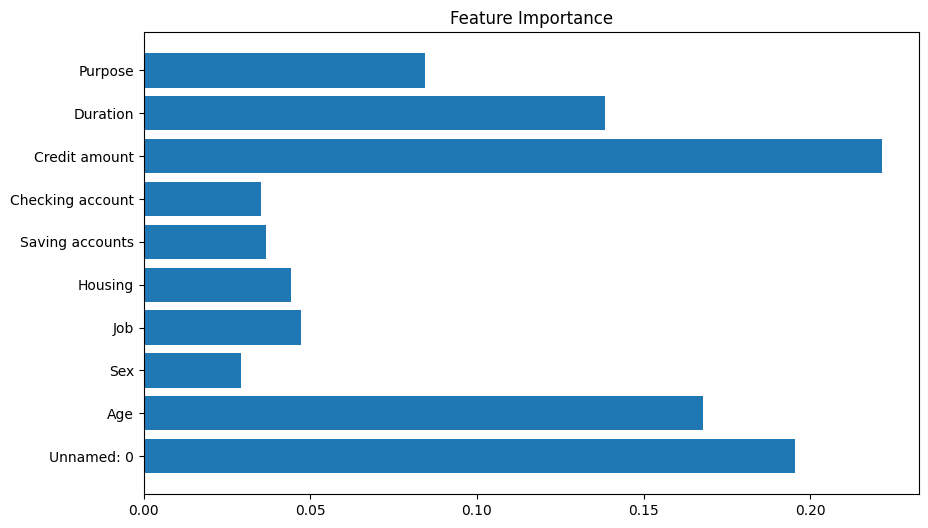

In [18]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(10,6))

plt.barh(features, importance)

plt.title("Feature Importance")

plt.show()

In [19]:
#as we got poor results

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc

Risk
1    700
0    300
Name: count, dtype: int64


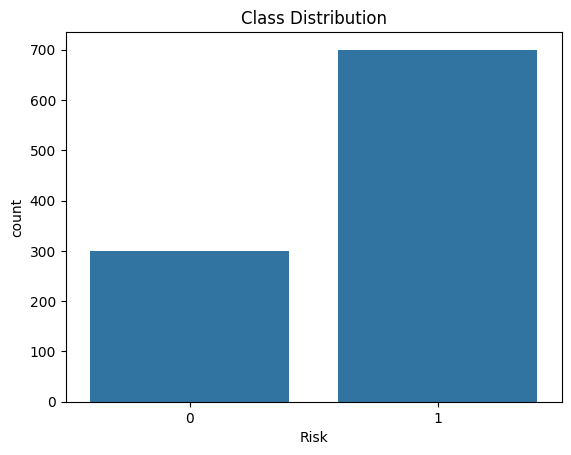

In [21]:
print(df["Risk"].value_counts())

sns.countplot(x='Risk', data=df)
plt.title("Class Distribution")
plt.show()

In [22]:
#imbalance in risk column
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

In [23]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_16388/1842323058.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [24]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [25]:
X = df.drop("Risk", axis=1)
y = df["Risk"]

In [26]:
#applying feature scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
#stratify preserves class balance

In [28]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)

print(y_train_balanced.value_counts())
#SMOTE creates synthetic examples for the minority class.

Risk
1    560
0    560
Name: count, dtype: int64


In [29]:
#trying multiple models

In [30]:
#logistic regression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.665


In [31]:
#decision tree classifier
dt = DecisionTreeClassifier(max_depth=5)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.69


In [32]:
#improved random forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.68


In [33]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.46      0.35      0.40        60
           1       0.75      0.82      0.78       140

    accuracy                           0.68       200
   macro avg       0.60      0.59      0.59       200
weighted avg       0.66      0.68      0.67       200



In [34]:
rf_probs = rf.predict_proba(X_test)[:, 1]

roc_score = roc_auc_score(y_test, rf_probs)

print("ROC-AUC:", roc_score)

ROC-AUC: 0.6441666666666667


In [35]:
#comparing with logistic regression
lr1 = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr1.fit(
    X_train_balanced,
    y_train_balanced
)

lr1_pred = lr1.predict(X_test)

print(classification_report(
    y_test,
    lr_pred
))

              precision    recall  f1-score   support

           0       0.27      0.07      0.11        60
           1       0.70      0.92      0.79       140

    accuracy                           0.67       200
   macro avg       0.48      0.49      0.45       200
weighted avg       0.57      0.67      0.59       200



In [36]:
#cross validation
cv_scores = cross_val_score(
    rf,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores)

print("Average CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.66 0.7  0.7  0.73 0.68]
Average CV Accuracy: 0.694


In [37]:
#hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced'),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


In [38]:
#train best model
best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.56      0.33      0.42        60
           1       0.76      0.89      0.82       140

    accuracy                           0.72       200
   macro avg       0.66      0.61      0.62       200
weighted avg       0.70      0.72      0.70       200



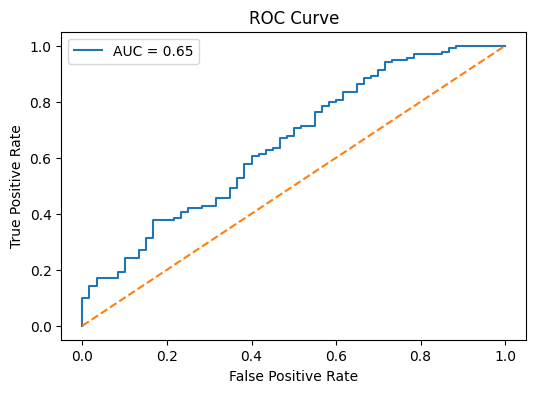

In [39]:
best_probs = best_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, best_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [40]:
#model comparision

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            class_weight='balanced'
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=5,
            class_weight='balanced'
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            max_depth=15,
            class_weight='balanced',
            random_state=42
        )
}

for name, model in models.items():

    model.fit(X_train_balanced, y_train_balanced)

    pred = model.predict(X_test)

    print("\n", name)
    print(classification_report(y_test, pred))


 Logistic Regression
              precision    recall  f1-score   support

           0       0.44      0.58      0.50        60
           1       0.79      0.69      0.74       140

    accuracy                           0.66       200
   macro avg       0.62      0.63      0.62       200
weighted avg       0.69      0.66      0.67       200


 Decision Tree
              precision    recall  f1-score   support

           0       0.38      0.50      0.43        60
           1       0.75      0.64      0.69       140

    accuracy                           0.60       200
   macro avg       0.56      0.57      0.56       200
weighted avg       0.64      0.60      0.61       200


 Random Forest
              precision    recall  f1-score   support

           0       0.41      0.33      0.37        60
           1       0.74      0.79      0.76       140

    accuracy                           0.66       200
   macro avg       0.57      0.56      0.56       200
weighted avg       0

In [43]:
#saving model
import joblib

joblib.dump(best_model, "credit_scoring_model.pkl")

['credit_scoring_model.pkl']

In [44]:
#saving scaler
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [45]:
from google.colab import files

files.download("credit_scoring_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

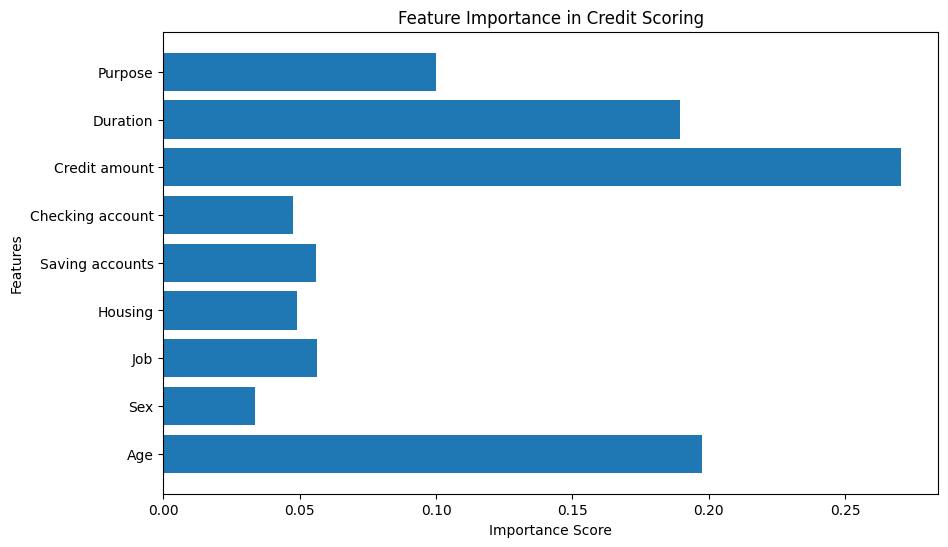

In [46]:
importance = best_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))

plt.barh(features, importance)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Credit Scoring")

plt.show()

In [47]:
plt.savefig("confusion_matrix.png", bbox_inches='tight')
plt.savefig("roc_curve.png", bbox_inches='tight')
plt.savefig("feature_importance.png", bbox_inches='tight')
from google.colab import files

files.download("confusion_matrix.png")
files.download("roc_curve.png")
files.download("feature_importance.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>